<a href="https://colab.research.google.com/github/J0irAtz/netflix-data-analisis/blob/main/Proyecto_Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# 1. Cargar la base de datos cruda

In [2]:
df = pd.read_csv('netflix_titles.csv')

In [3]:
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (8807, 12)


In [4]:
print(df.dtypes)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [5]:
rows_number = df.shape[0]
print(rows_number)

8807


In [6]:
columns_number = df.shape[1]
print(columns_number)

12


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
print(df.isna().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [11]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [12]:
df["duration"].value_counts()

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
...,...
228 min,1
18 min,1
205 min,1


# 1. Creamos un nuevo DataFrame filtrando solo donde el tipo sea 'Movie'

In [13]:
df_peliculas = df[df["type"] == "Movie"].copy()

In [14]:
df_peliculas = df_peliculas.dropna(subset=['duration'])

In [15]:
df_peliculas['duracion_minutos'] = df_peliculas['duration'].str.replace(' min', '').astype(int)

In [16]:
print(df_peliculas[['title', 'duration', 'duracion_minutos']].head())

                               title duration  duracion_minutos
0               Dick Johnson Is Dead   90 min                90
6   My Little Pony: A New Generation   91 min                91
7                            Sankofa  125 min               125
9                       The Starling  104 min               104
12                      Je Suis Karl  127 min               127


# 1. Agrupamos por año y calculamos el promedio de nuestra nueva columna matemática

In [17]:
tendencia_duracion = df_peliculas.groupby('release_year')['duracion_minutos'].mean().round(1).reset_index()
tendencia_moderna = tendencia_duracion[tendencia_duracion['release_year'] >= 2000]
print(tendencia_moderna.tail(15))

    release_year  duracion_minutos
58          2007             113.2
59          2008             106.2
60          2009             108.9
61          2010             104.5
62          2011             102.9
63          2012             100.8
64          2013              98.0
65          2014             100.3
66          2015              99.5
67          2016              95.4
68          2017              95.5
69          2018              96.2
70          2019              93.5
71          2020              92.1
72          2021              96.4


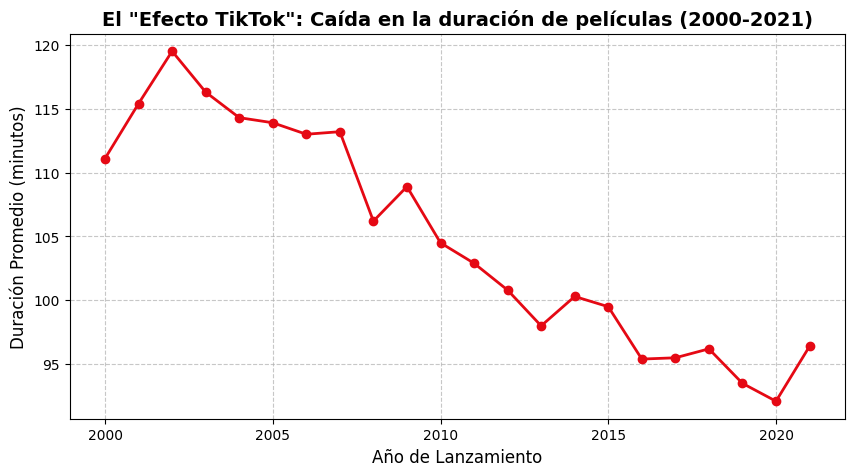

In [18]:
import matplotlib.pyplot as plt

# Configuramos el tamaño del lienzo
plt.figure(figsize=(10, 5))

# Dibujamos la línea roja de Netflix
plt.plot(tendencia_moderna['release_year'], tendencia_moderna['duracion_minutos'],
         marker='o', color='#E50914', linewidth=2)

# Le ponemos títulos profesionales
plt.title('El "Efecto TikTok": Caída en la duración de películas (2000-2021)', fontsize=14, fontweight='bold')
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Duración Promedio (minutos)', fontsize=12)

# Cuadrícula para que sea fácil de leer
plt.grid(True, linestyle='--', alpha=0.7)

# Mostramos la gráfica
plt.show()

Fase 2

In [19]:
df_calificaciones = pd.read_csv("Netflix TV Shows and Movies.csv")
df_calificaciones.head()

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0


In [20]:
df_calificaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5283 non-null   int64  
 1   id                 5283 non-null   object 
 2   title              5283 non-null   object 
 3   type               5283 non-null   object 
 4   description        5278 non-null   object 
 5   release_year       5283 non-null   int64  
 6   age_certification  2998 non-null   object 
 7   runtime            5283 non-null   int64  
 8   imdb_id            5283 non-null   object 
 9   imdb_score         5283 non-null   float64
 10  imdb_votes         5267 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 454.1+ KB


In [21]:
# 1. De la tabla de IMDb, solo recortare el título (puente) y las calificaciones
columnas_utiles = df_calificaciones[['title', 'imdb_score', 'imdb_votes']]

# 2. Hare la fusión usando pd.merge()
df_enriquecido = pd.merge(df_peliculas, columnas_utiles, on='title', how='left')

# 3. Comprobare las dimensiones y vemos una muestra
print(df_enriquecido.shape)
df_enriquecido[['title', 'duracion_minutos', 'imdb_score', 'imdb_votes']].head()

(6155, 15)


,title,duracion_minutos,imdb_score,imdb_votes
0,Dick Johnson Is Dead,90,7.4,6390.0
1,My Little Pony: A New Generation,91,6.8,3468.0
2,Sankofa,125,7.0,678.0
3,The Starling,104,6.3,11733.0
4,Je Suis Karl,127,NaN,NaN


In [22]:
df_enriquecido.isnull().sum()

,0
show_id,0
type,0
title,0
director,188
cast,475
country,442
date_added,0
release_year,0
rating,2
duration,0


In [23]:
# 1. Creo una tabla exclusiva borrando solo los que no tienen calificación
df_top_peliculas = df_enriquecido.dropna(subset=['imdb_score']).copy()

# 2. Ordeno de mayor a menor (ascending=False) y sacamos el Top 10
top_10 = df_top_peliculas.sort_values(by='imdb_score', ascending=False).head(10)

# 3. Imprimo el resultado con las columnas más importantes
top_10[['title', 'release_year', 'imdb_score', 'imdb_votes']]

,title,release_year,imdb_score,imdb_votes
1242,David Attenborough: A Life on Our Planet,2020,9.0,31180.0
1359,Sky Tour: The Movie,2020,8.8,1036.0
216,Inception,2010,8.8,2268288.0
1639,Bye Bye London,1981,8.7,154.0
532,Bo Burnham: Inside,2021,8.7,44074.0
1243,"Best Wishes, Warmest Regards: A Schitt's Creek...",2020,8.6,1357.0
586,In Our Mothers' Gardens,2020,8.6,124.0
2699,Merku Thodarchi Malai,2018,8.6,1810.0
2595,A Second Chance,2015,8.6,47.0
1328,Ani... Dr. Kashinath Ghanekar,2018,8.5,1071.0


In [24]:
# Filtro para que solo participen películas con más de 10,000 votos antes de ordenar
top_10 = df_top_peliculas[df_top_peliculas['imdb_votes'] > 10000].sort_values(by='imdb_score', ascending=False).head(10)

In [25]:
top_10[['title', 'release_year', 'imdb_score', 'imdb_votes']]

,title,release_year,imdb_score,imdb_votes
1242,David Attenborough: A Life on Our Planet,2020,9.0,31180.0
216,Inception,2010,8.8,2268288.0
532,Bo Burnham: Inside,2021,8.7,44074.0
3792,Bo Burnham: Make Happy,2016,8.4,14356.0
737,3 Idiots,2009,8.4,385782.0
2312,Dave Chappelle: Sticks & Stones,2019,8.4,25687.0
252,Django Unchained,2012,8.4,1472668.0
1099,Black Friday,2004,8.4,20611.0
3501,Dangal,2016,8.4,180247.0
2383,Super Deluxe,2019,8.4,13680.0


Arrancando la Fase 3: Idea B (Oportunidades de Negocio)

In [26]:
# Cómo guardó Netflix las categorías de las películas
df_top_peliculas[['title', 'listed_in']].head(10)

,title,listed_in
0,Dick Johnson Is Dead,Documentaries
1,My Little Pony: A New Generation,Children & Family Movies
2,Sankofa,"Dramas, Independent Movies, International Movies"
3,The Starling,"Comedies, Dramas"
5,Confessions of an Invisible Girl,"Children & Family Movies, Comedies"
7,Intrusion,Thrillers
10,Jeans,"Comedies, International Movies, Romantic Movies"
11,Minsara Kanavu,"Comedies, International Movies, Music & Musicals"
12,Grown Ups,Comedies
13,Dark Skies,"Horror Movies, Sci-Fi & Fantasy"


In [27]:
# 1. SeparO el texto por las comas, creando una lista interna de géneros
df_top_peliculas['genero_individual'] = df_top_peliculas['listed_in'].str.split(', ')

# 2. ExplotO la lista: si una película tiene 3 géneros, se duplicará en 3 filas independientes
df_generos = df_top_peliculas.explode('genero_individual')

# 3. ComparO la columna original con la nueva
df_generos[['title', 'listed_in', 'genero_individual']].head(6)

,title,listed_in,genero_individual
0,Dick Johnson Is Dead,Documentaries,Documentaries
1,My Little Pony: A New Generation,Children & Family Movies,Children & Family Movies
2,Sankofa,"Dramas, Independent Movies, International Movies",Dramas
2,Sankofa,"Dramas, Independent Movies, International Movies",Independent Movies
2,Sankofa,"Dramas, Independent Movies, International Movies",International Movies
3,The Starling,"Comedies, Dramas",Comedies


In [28]:
# 1. AgrupO por género, calculamos el promedio de calificación y contamos las películas
rendimiento_generos = df_generos.groupby('genero_individual').agg(
    calificacion_promedio=('imdb_score', 'mean'),
    cantidad_peliculas=('title', 'count')
).round(2).reset_index()

# 2. FiltrO géneros de nicho exigiendo un mínimo de 50 películas producidas
generos_robustos = rendimiento_generos[rendimiento_generos['cantidad_peliculas'] >= 50]

# 3. OrdenO de mayor a menor calificación para obtener el Top 5
top_5_generos = generos_robustos.sort_values(by='calificacion_promedio', ascending=False).head(5)

print(top_5_generos)

     genero_individual  calificacion_promedio  cantidad_peliculas
6        Documentaries                   6.97                 268
18     Stand-Up Comedy                   6.66                 211
17       Sports Movies                   6.44                  72
7               Dramas                   6.36                1035
10  Independent Movies                   6.33                 286
